In [36]:
from embeddings import (
    plot_embeddings,
    sensitive_pars,
)

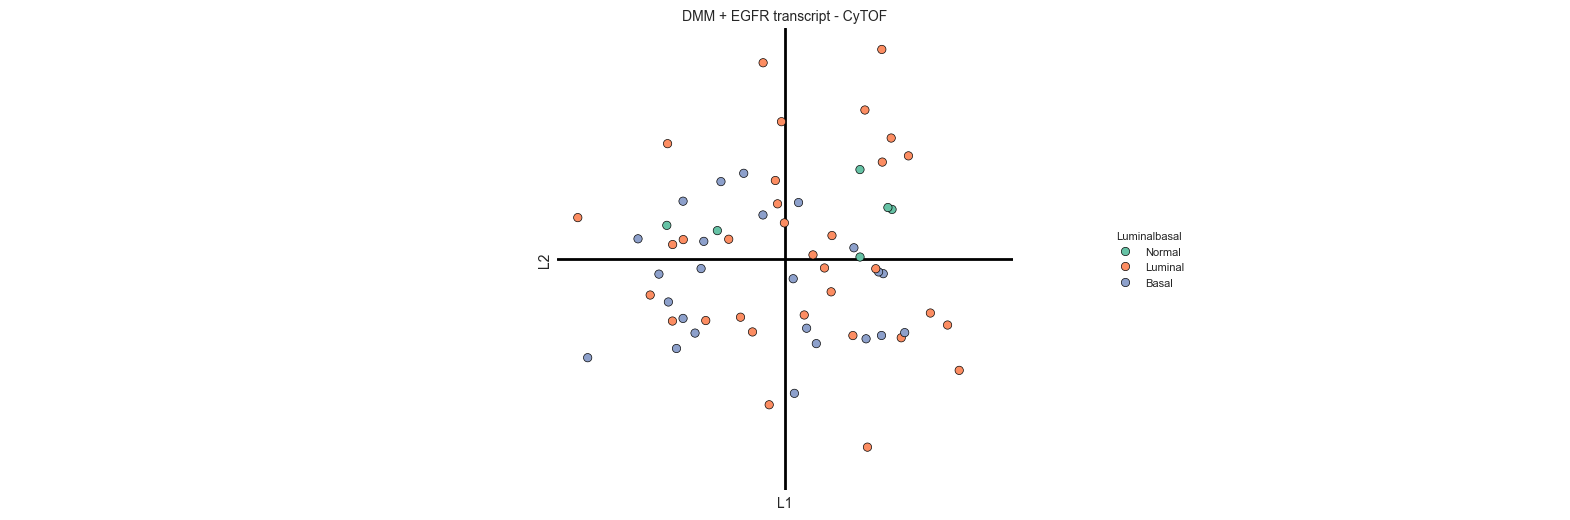

In [37]:
# Example: Plot with luminalbasal coloring
plot_embeddings(
    model="EGFR_MAPK__logobs_tegfr_aggavg",
    context="cytof_init",
    color_by="luminalbasal",
    save_path="embedding_cytof_tegfr.eps",
    palette="Set2"
);

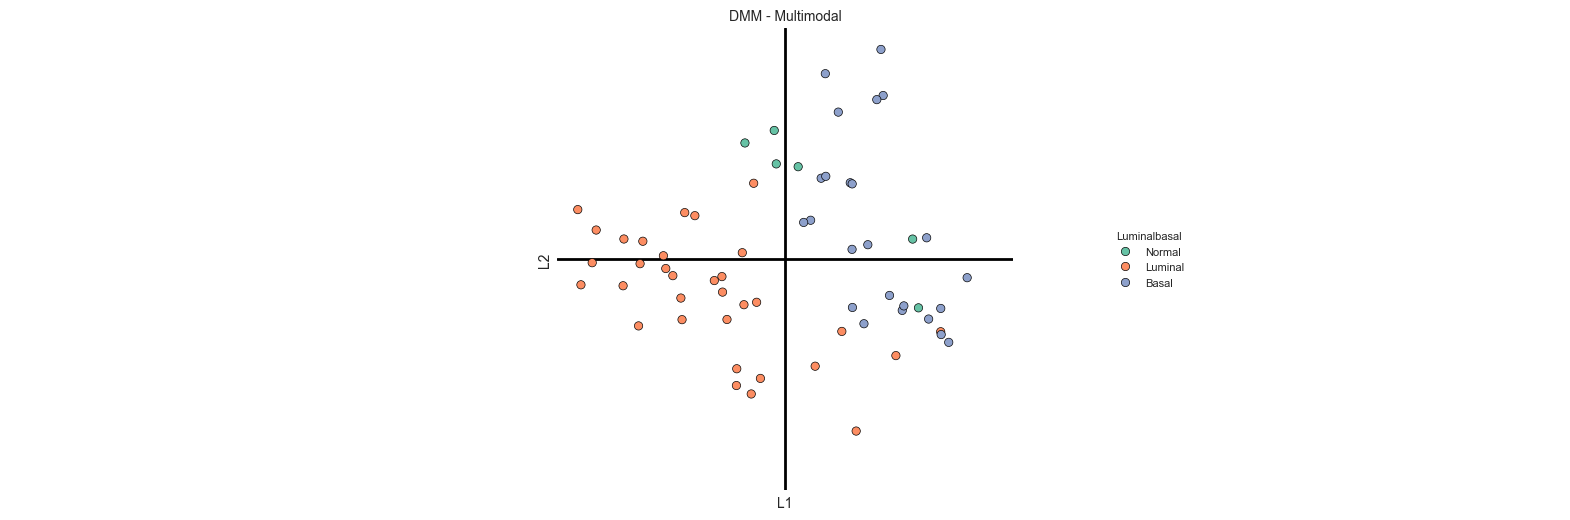

In [38]:
plot_embeddings(
    model="EGFR_MAPK__logobs",
    context="multimodal",
    color_by="luminalbasal",
    save_path="embedding_multimodal_base.eps",
    palette="Set2",
);

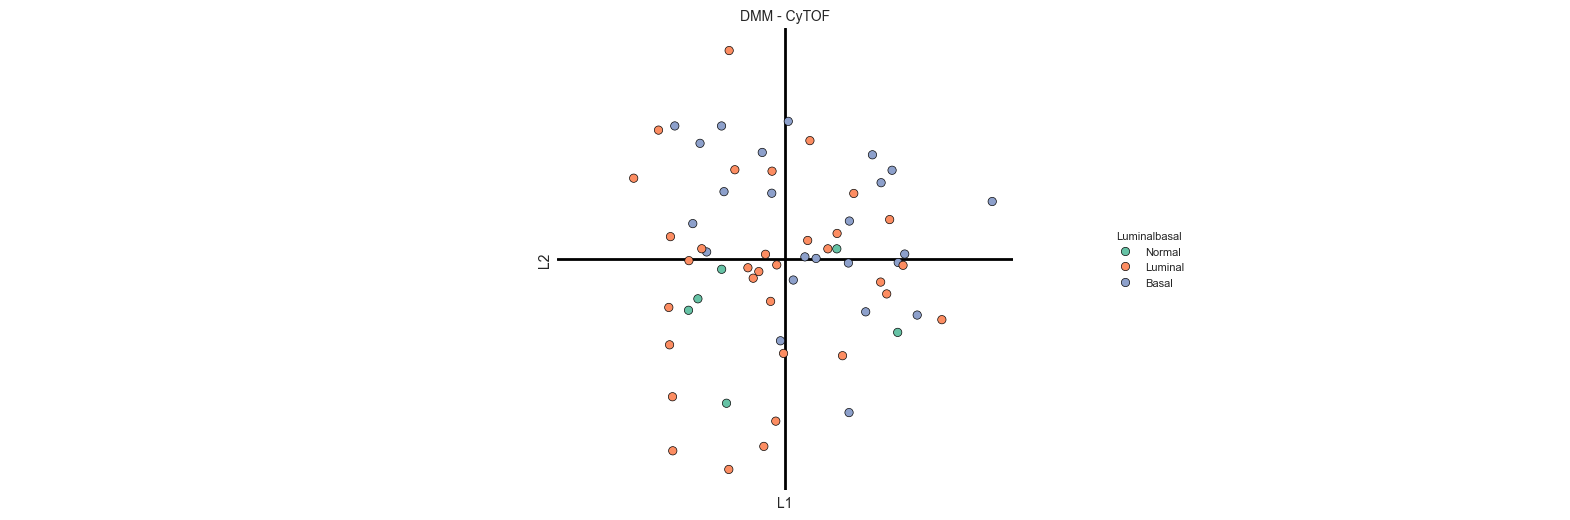

In [39]:
plot_embeddings(
    model="EGFR_MAPK__logobs",
    context="cytof_init",
    color_by="luminalbasal",
    save_path="embedding_multimodal_base.eps",
    palette="Set2",
);

## Luminal vs Basal Classification from Embeddings

Evaluate how well embeddings separate luminal from basal cell lines using cross-validated classifiers.

In [40]:
import sys
from pathlib import Path

import pandas as pd

# Ensure project root is on sys.path so we can import common, embedding_utils, etc.
_project_root = str(Path.cwd().parent)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from embedding_utils import evaluate_luminal_basal_classifier, plot_luminal_basal_performance
from common import subtypes_tognetti
from embeddings import load_embedding_data, prepare_pca_embeddings, load_marcotte_subtypes

# Load and PCA-transform embeddings once
embedding_df = load_embedding_data(figure="figure3")
subtypes_df = load_marcotte_subtypes(embedding_df.cell_line.unique())
pca_embedding_df = prepare_pca_embeddings(embedding_df, subtypes_df)

# Reset index so cell_line is a column (PCA sets it as index)
if pca_embedding_df.index.name == "cell_line":
    pca_embedding_df = pca_embedding_df.reset_index()

# Configurations to evaluate
models = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
contexts = ["cytof_init", "multimodal"]
classifiers = ["svm", "logreg", "rf"]

all_results = []
for model in models:
    for context in contexts:
        emb_df = pca_embedding_df[
            (pca_embedding_df["model"] == model) &
            (pca_embedding_df["context"] == context)
        ].copy()
        if emb_df.empty:
            print(f"Skipping {model}/{context}: no embeddings found")
            continue
        for clf in classifiers:
            res = evaluate_luminal_basal_classifier(
                embeddings_df=emb_df,
                subtype_mapping=subtypes_tognetti,
                classifier=clf,
                group_cols=["context", "samples"],
            )
            if not res.empty:
                res["model"] = model
                all_results.append(res)

if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
    display(results_df)
else:
    print("No results generated.")

,context,samples,classifier,n_samples,n_splits,n_features,accuracy,roc_auc,model
0,cytof_init,all,svm,48,5,4,0.711111,0.860,EGFR_MAPK__logobs
1,cytof_init,all,logreg,48,5,4,0.688889,0.876,EGFR_MAPK__logobs
2,cytof_init,all,rf,48,5,4,0.600000,0.690,EGFR_MAPK__logobs
3,multimodal,all,svm,48,5,4,0.960000,1.000,EGFR_MAPK__logobs
4,multimodal,all,logreg,48,5,4,0.960000,1.000,EGFR_MAPK__logobs
5,multimodal,all,rf,48,5,4,0.915556,0.992,EGFR_MAPK__logobs
6,cytof_init,all,svm,48,5,4,0.606667,0.742,EGFR_MAPK__logobs_tegfr_aggavg
7,cytof_init,all,logreg,48,5,4,0.562222,0.718,EGFR_MAPK__logobs_tegfr_aggavg
8,cytof_init,all,rf,48,5,4,0.566667,0.542,EGFR_MAPK__logobs_tegfr_aggavg
9,multimodal,all,svm,48,5,4,0.980000,0.992,EGFR_MAPK__logobs_tegfr_aggavg


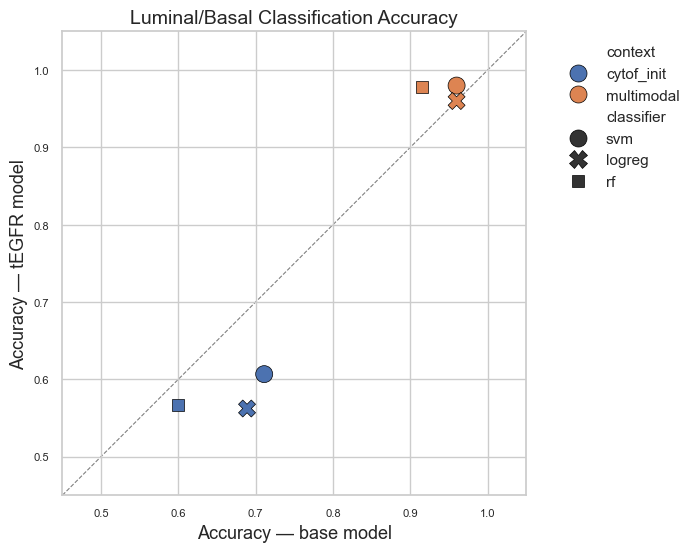

In [41]:
import seaborn as sns, matplotlib.pyplot as plt
import numpy as np

METRIC_LABELS = {"accuracy": "Accuracy", "roc_auc": "AUROC"}

def scatter_model_comparison(results_df, metric, title):
    """Scatter: x = base model, y = tegfr model, one point per (context, classifier)."""
    label = METRIC_LABELS.get(metric, metric)
    base = results_df[results_df["model"] == "EGFR_MAPK__logobs"].rename(columns={metric: "base"})
    tegfr = results_df[results_df["model"] == "EGFR_MAPK__logobs_tegfr_aggavg"].rename(columns={metric: "tegfr"})
    merged = base[["context", "samples", "classifier", "base"]].merge(
        tegfr[["context", "samples", "classifier", "tegfr"]],
        on=["context", "samples", "classifier"],
    )

    fig, ax = plt.subplots(figsize=(7, 7))
    sns.scatterplot(
        data=merged, x="base", y="tegfr",
        hue="context", style="classifier",
        s=150, edgecolor="black", linewidth=0.5, ax=ax,
    )
    lo, hi = 0.45, 1.05
    ticks = np.arange(0.5, 1.05, 0.1)
    ax.plot([lo, hi], [lo, hi], ls="--", color="grey", lw=0.8, zorder=0)
    ax.set(xlim=(lo, hi), ylim=(lo, hi))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xlabel(f"{label} — base model", fontsize=13)
    ax.set_ylabel(f"{label} — tEGFR model", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=11)
    plt.tight_layout()
    plt.show()

if all_results:
    scatter_model_comparison(results_df, "accuracy", "Luminal/Basal Classification Accuracy")

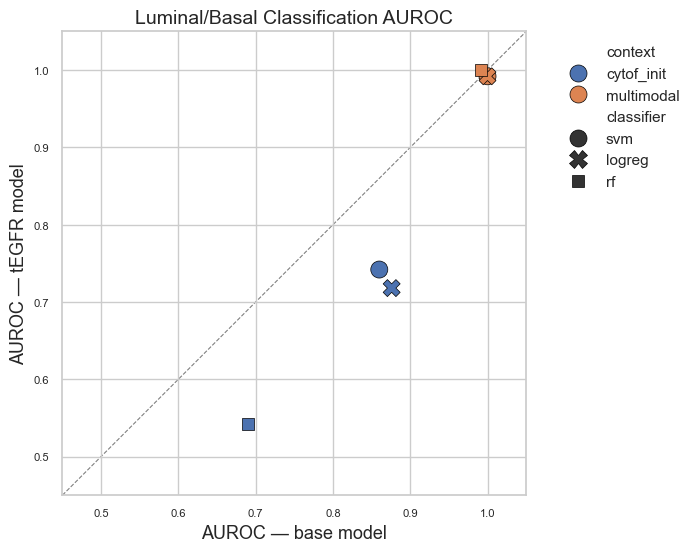

In [42]:
if all_results:
    scatter_model_comparison(results_df, "roc_auc", "Luminal/Basal Classification AUROC")

## Classifier comparison across all available annotations

Evaluate how well embeddings separate cell lines according to **every** available categorical annotation:
- **Marcotte subtypes** (intrinsic, Neve, three-receptor, claudin-low, Curtis, Lehmann TNBC, Marcotte clusters, RPPA, screen-unsupervised)
- **Receptor status** (AR, ESR1, ERBB2, PGR high/low)
- **Cellosaurus** (MSI status, site of origin, disease, population, category)
- **cBioPortal CCLE** (per-gene mutation status for frequently mutated genes, TMB high/low, dominant mutation type, pathway-level mutation status)
- **Luminal / Basal** (collapsed intrinsic subtypes)
- **PAM50** (Tognetti mapping)

In [43]:
import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd

_project_root = str(Path.cwd().parent)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import embedding_utils
importlib.reload(embedding_utils)
from embedding_utils import evaluate_annotation_classifier

from embeddings import load_embedding_data, prepare_pca_embeddings, load_marcotte_subtypes
from cell_line_annotations import (
    get_cellosaurus_annotations, get_subtype_annotations,
    fetch_cbioportal_mutations, fetch_cmp_driver_genes,
)
from common import basedir, features_dir, subtypes_tognetti

# ── Load embeddings (reuse if already loaded above) ──
try:
    _ = pca_embedding_df
    print("Reusing existing pca_embedding_df")
except NameError:
    embedding_df = load_embedding_data(figure="figure3")
    subtypes_df = load_marcotte_subtypes(embedding_df.cell_line.unique())
    pca_embedding_df = prepare_pca_embeddings(embedding_df, subtypes_df)

if pca_embedding_df.index.name == "cell_line":
    pca_clf_df = pca_embedding_df.reset_index()
else:
    pca_clf_df = pca_embedding_df.copy()

cell_lines = sorted(pca_clf_df["cell_line"].unique())
print(f"{len(cell_lines)} cell lines in embeddings")

# ═══════════════════════════════════════════════════════════════════════
# 1. Marcotte / subtype annotations from cell_line_subtypes.txt
# ═══════════════════════════════════════════════════════════════════════
marc = load_marcotte_subtypes(cell_lines)

annotation_sources: dict[str, pd.Series] = {}

# Categorical subtypes
for col in [
    "subtype_intrinsic", "subtype_neve", "subtype_claudin_low",
    "subtype_three_receptor", "subtype_curtis", "subtype_lehmann_tnbc",
    "subtype_marcotte", "subtype_rppa", "subtype_screen_unsupervised",
]:
    if col in marc.columns:
        ser = marc[col].dropna()
        if ser.nunique() >= 2:
            annotation_sources[col] = ser

# Receptor status (binary high/low)
for col in ["status_AR", "status_ESR1", "status_ERBB2", "status_PGR"]:
    if col in marc.columns:
        ser = marc[col].dropna()
        if ser.nunique() >= 2:
            annotation_sources[col] = ser

# Luminal / Basal (collapsed from intrinsic)
if "subtype_intrinsic" in marc.columns:
    lb = marc["subtype_intrinsic"].copy()
    lb = lb.replace({"LuminalA": "Luminal", "LuminalB": "Luminal", "HER2": "Luminal", "CL": "Basal"})
    lb = lb[lb.isin(["Luminal", "Basal"])]
    annotation_sources["luminal_basal"] = lb

# ═══════════════════════════════════════════════════════════════════════
# 2. Cellosaurus annotations
# ═══════════════════════════════════════════════════════════════════════
try:
    cello_annot, _, _, _ = get_cellosaurus_annotations(
        cell_lines, file_dir=features_dir, cache_dir=features_dir,
    )
    for col, label in [
        ("MS_Status", "cellosaurus_MSI"),
        ("Site", "cellosaurus_site"),
        ("Disease", "cellosaurus_disease"),
        ("Population", "cellosaurus_population"),
        ("Category", "cellosaurus_category"),
    ]:
        if col in cello_annot.columns:
            ser = cello_annot[col].replace("Unknown", np.nan).dropna()
            if ser.nunique() >= 2:
                annotation_sources[label] = ser
    print(f"Cellosaurus annotations added")
except Exception as e:
    print(f"Cellosaurus annotations skipped: {e}")

# ═══════════════════════════════════════════════════════════════════════
# 3. PAM50 from Tognetti mapping
# ═══════════════════════════════════════════════════════════════════════
pam50_ser = pd.Series(
    {cl: subtypes_tognetti[cl]["PAM50"] for cl in cell_lines if cl in subtypes_tognetti},
    name="PAM50",
)
pam50_ser = pam50_ser[pam50_ser != "Unknown"].dropna()
if pam50_ser.nunique() >= 2:
    annotation_sources["PAM50_tognetti"] = pam50_ser

# ═══════════════════════════════════════════════════════════════════════
# 4. cBioPortal CCLE mutations
# ═══════════════════════════════════════════════════════════════════════
MIN_GENE_FREQ = 8  # gene must be mutated in ≥ this many cell lines

try:
    cbio_df = fetch_cbioportal_mutations(cell_lines, cache_dir=features_dir)
    driver_genes = fetch_cmp_driver_genes(cache_dir=features_dir)

    # 4a. Per-gene mutation status — restrict to cancer driver genes
    gene_cl = cbio_df.groupby("gene")["cell_line"].nunique()
    freq_genes = gene_cl[
        (gene_cl >= MIN_GENE_FREQ) & (gene_cl.index.isin(driver_genes))
    ].index.tolist()
    print(f"  cBioPortal: {len(freq_genes)} driver genes mutated in ≥{MIN_GENE_FREQ} cell lines")

    for gene in sorted(freq_genes):
        mutated_cls = set(cbio_df[cbio_df["gene"] == gene]["cell_line"])
        ser = pd.Series(
            {cl: ("mutated" if cl in mutated_cls else "WT") for cl in cell_lines
             if cl in cbio_df["cell_line"].values or cl not in mutated_cls},
        )
        # Only keep if both classes have ≥ 3 members among our cell lines
        vc = ser.value_counts()
        if len(vc) >= 2 and vc.min() >= 3:
            annotation_sources[f"cbio_{gene}_mut"] = ser

    # 4b. TMB high vs low (median split)
    tmb = cbio_df.groupby("cell_line")["gene"].nunique().rename("TMB")
    tmb = tmb.reindex(cell_lines, fill_value=0)
    tmb_med = tmb.median()
    tmb_label = tmb.map(lambda x: "TMB_high" if x > tmb_med else "TMB_low")
    if tmb_label.nunique() >= 2:
        annotation_sources["cbio_TMB_highlow"] = tmb_label

    # 4c. Dominant mutation type per cell line
    if "mutationType" in cbio_df.columns:
        dom_mt = (
            cbio_df.groupby(["cell_line", "mutationType"]).size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
            .drop_duplicates(subset="cell_line", keep="first")
            .set_index("cell_line")["mutationType"]
        )
        dom_mt = dom_mt.reindex([cl for cl in cell_lines if cl in dom_mt.index])
        vc = dom_mt.value_counts()
        keep = vc[vc >= 3].index
        dom_mt = dom_mt[dom_mt.isin(keep)]
        if dom_mt.nunique() >= 2:
            annotation_sources["cbio_dominant_muttype"] = dom_mt

    # 4d. Any PIK3CA/TP53/ERBB2 pathway-level grouping
    pathway_genes = {
        "PI3K_pathway": {"PIK3CA", "PIK3R1", "AKT1", "PTEN", "MTOR"},
        "TP53_pathway": {"TP53", "MDM2", "ATM", "CHEK2"},
        "MAPK_pathway": {"KRAS", "NRAS", "BRAF", "MAP2K1", "MAP3K1", "NF1"},
        "chromatin_remodeling": {"ARID1A", "KMT2C", "KMT2D", "SETD2"},
    }
    for pw_name, pw_genes in pathway_genes.items():
        pw_cls = set(cbio_df[cbio_df["gene"].isin(pw_genes)]["cell_line"])
        ser = pd.Series(
            {cl: ("mutated" if cl in pw_cls else "WT") for cl in cell_lines},
        )
        vc = ser.value_counts()
        if len(vc) >= 2 and vc.min() >= 3:
            annotation_sources[f"cbio_{pw_name}"] = ser

    print(f"  cBioPortal annotations added (per-gene + TMB + muttype + pathways)")
except Exception as e:
    print(f"cBioPortal annotations skipped: {e}")

print(f"\n{'='*60}")
print(f"Total annotation sources: {len(annotation_sources)}")
for name, ser in annotation_sources.items():
    print(f"  {name:35s}  {ser.nunique():2d} classes,  {len(ser):3d} samples")
print(f"{'='*60}")

Reusing existing pca_embedding_df
63 cell lines in embeddings
  [cache hit] Cellosaurus annotations loaded from cache
Cellosaurus annotations added
  [cache hit] cBioPortal mutations loaded from cache
  [cache hit] 791 CMP driver genes loaded from cache
  cBioPortal: 21 driver genes mutated in ≥8 cell lines
  cBioPortal annotations added (per-gene + TMB + muttype + pathways)

Total annotation sources: 46
  subtype_intrinsic                     6 classes,   63 samples
  subtype_neve                          4 classes,   63 samples
  subtype_claudin_low                   2 classes,   63 samples
  subtype_three_receptor                3 classes,   63 samples
  subtype_curtis                       10 classes,   63 samples
  subtype_lehmann_tnbc                  7 classes,   32 samples
  subtype_marcotte                      7 classes,   63 samples
  subtype_rppa                          8 classes,   63 samples
  subtype_screen_unsupervised           6 classes,   59 samples
  status_AR     

In [44]:
# ── Run classifiers for every annotation × model × context ──
models = ["EGFR_MAPK__logobs_tegfr_aggavg"]
contexts = ["cytof_init", "multimodal"]
classifiers = ["svm", "logreg"]

all_annot_results = []
all_importance_records = []

for annot_name, annot_ser in annotation_sources.items():
    for model in models:
        for context in contexts:
            emb = pca_clf_df[
                (pca_clf_df["model"] == model) & (pca_clf_df["context"] == context)
            ].copy()
            if emb.empty:
                continue
            for clf in classifiers:
                res, imp = evaluate_annotation_classifier(
                    embeddings_df=emb,
                    annotation_series=annot_ser,
                    annotation_name=annot_name,
                    classifier=clf,
                    group_cols=["context", "samples"],
                    min_class_count=3,
                    return_feature_importances=True,
                )
                if not res.empty:
                    res["model"] = model
                    all_annot_results.append(res)
                if not imp.empty:
                    imp["model"] = model
                    all_importance_records.append(imp)

annot_results_df = pd.concat(all_annot_results, ignore_index=True) if all_annot_results else pd.DataFrame()
importance_df = pd.concat(all_importance_records, ignore_index=True) if all_importance_records else pd.DataFrame()

# Unify metric columns
for col in ["roc_auc", "macro_f1", "balanced_accuracy", "chance_accuracy", "chance_balanced"]:
    if col not in annot_results_df.columns:
        annot_results_df[col] = np.nan

print(f"Total classification results: {len(annot_results_df)} rows")
print(f"Annotations evaluated: {annot_results_df['annotation'].nunique()}")
print(f"Feature importance records: {len(importance_df)} rows")
annot_results_df.head(10)

Total classification results: 184 rows
Annotations evaluated: 46
Feature importance records: 736 rows


,context,samples,annotation,classifier,n_classes,n_samples,n_splits,n_features,accuracy,balanced_accuracy,chance_accuracy,chance_balanced,macro_f1,model,roc_auc
0,cytof_init,all,subtype_intrinsic,svm,6,63,5,4,0.220513,0.225000,0.269841,0.166667,0.205079,EGFR_MAPK__logobs_tegfr_aggavg,NaN
1,cytof_init,all,subtype_intrinsic,logreg,6,63,5,4,0.206410,0.216667,0.269841,0.166667,0.160079,EGFR_MAPK__logobs_tegfr_aggavg,NaN
2,multimodal,all,subtype_intrinsic,svm,6,63,5,4,0.457692,0.455556,0.269841,0.166667,0.423889,EGFR_MAPK__logobs_tegfr_aggavg,NaN
3,multimodal,all,subtype_intrinsic,logreg,6,63,5,4,0.411538,0.425000,0.269841,0.166667,0.374444,EGFR_MAPK__logobs_tegfr_aggavg,NaN
4,cytof_init,all,subtype_neve,svm,4,63,5,4,0.269231,0.295833,0.317460,0.250000,0.246389,EGFR_MAPK__logobs_tegfr_aggavg,NaN
5,cytof_init,all,subtype_neve,logreg,4,63,5,4,0.301282,0.312500,0.317460,0.250000,0.274960,EGFR_MAPK__logobs_tegfr_aggavg,NaN
6,multimodal,all,subtype_neve,svm,4,63,5,4,0.589744,0.600000,0.317460,0.250000,0.573413,EGFR_MAPK__logobs_tegfr_aggavg,NaN
7,multimodal,all,subtype_neve,logreg,4,63,5,4,0.557692,0.570833,0.317460,0.250000,0.549484,EGFR_MAPK__logobs_tegfr_aggavg,NaN
8,cytof_init,all,subtype_claudin_low,svm,2,63,5,4,0.652564,0.584545,0.857143,0.500000,NaN,EGFR_MAPK__logobs_tegfr_aggavg,0.661818
9,cytof_init,all,subtype_claudin_low,logreg,2,63,5,4,0.637179,0.666364,0.857143,0.500000,NaN,EGFR_MAPK__logobs_tegfr_aggavg,0.680000


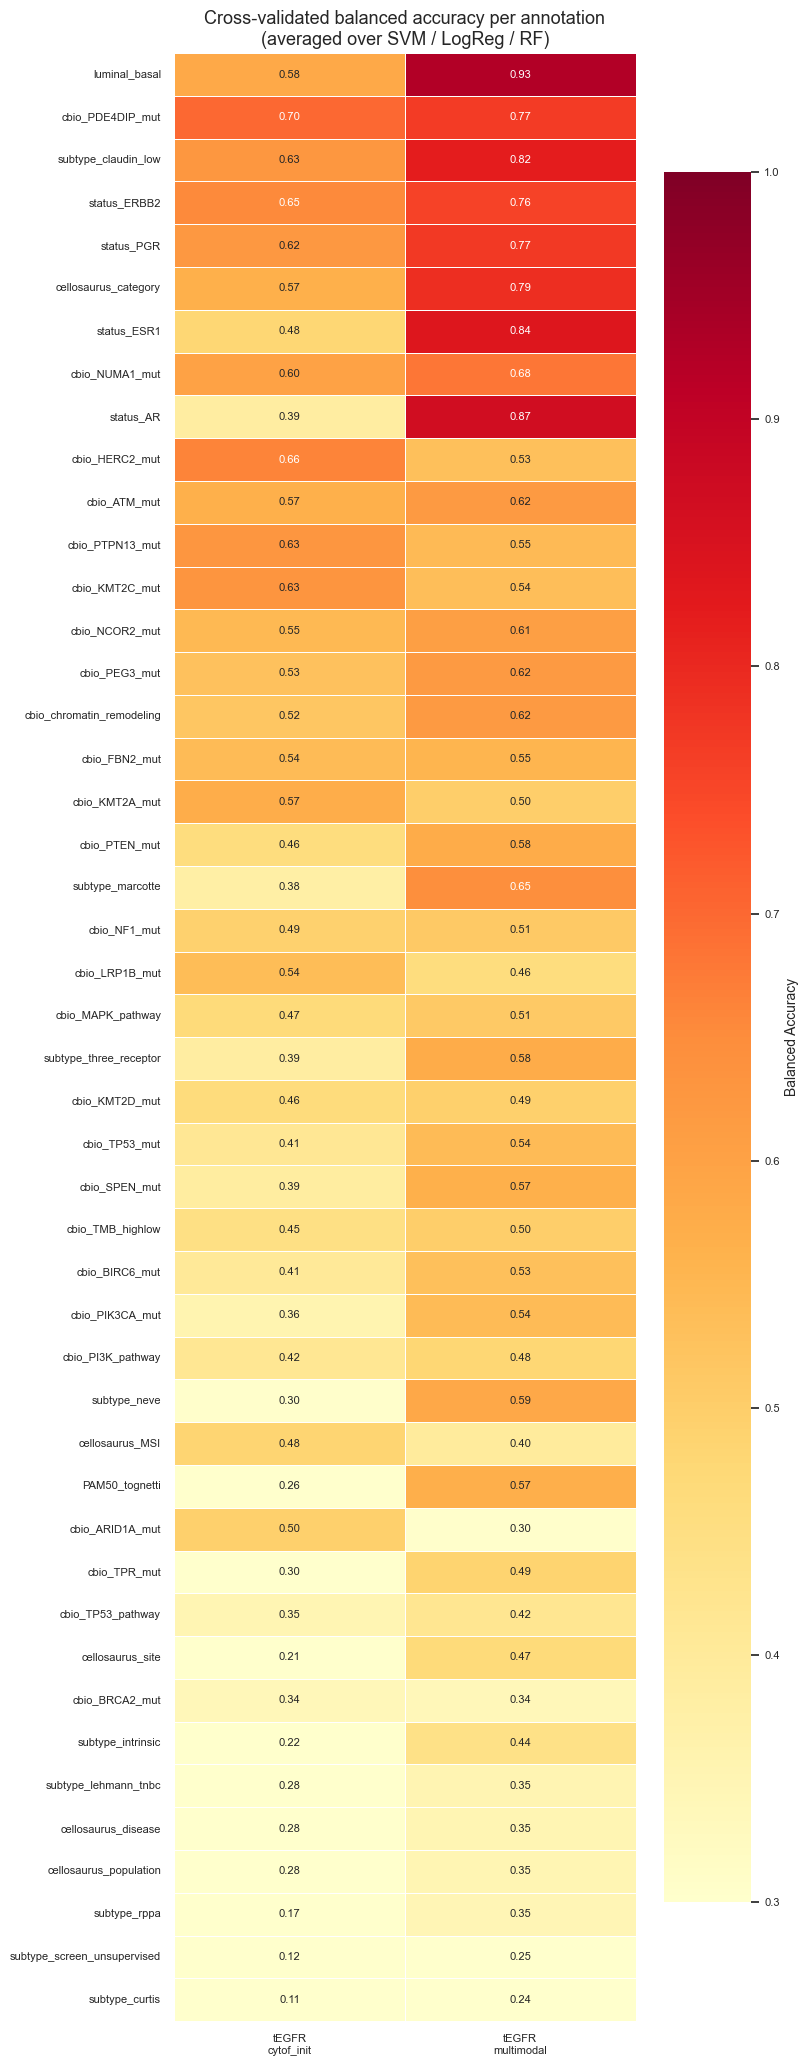

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Heatmap: mean balanced accuracy per annotation × (model, context), averaged over classifiers ──
pivot = annot_results_df.groupby(["annotation", "model", "context"])["balanced_accuracy"].mean().reset_index()
pivot["config"] = pivot["model"].str.replace("EGFR_MAPK__logobs", "base").str.replace("base_tegfr_aggavg", "tEGFR") + "\n" + pivot["context"]
heat = pivot.pivot(index="annotation", columns="config", values="balanced_accuracy")

# Sort rows by mean balanced accuracy (best at top)
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, max(5, 0.45 * len(heat))))
sns.heatmap(
    heat, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0.3, vmax=1.0,
    linewidths=0.5, ax=ax, cbar_kws={"label": "Balanced Accuracy"},
)
ax.set_title("Cross-validated balanced accuracy per annotation\n(averaged over SVM / LogReg / RF)", fontsize=13)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

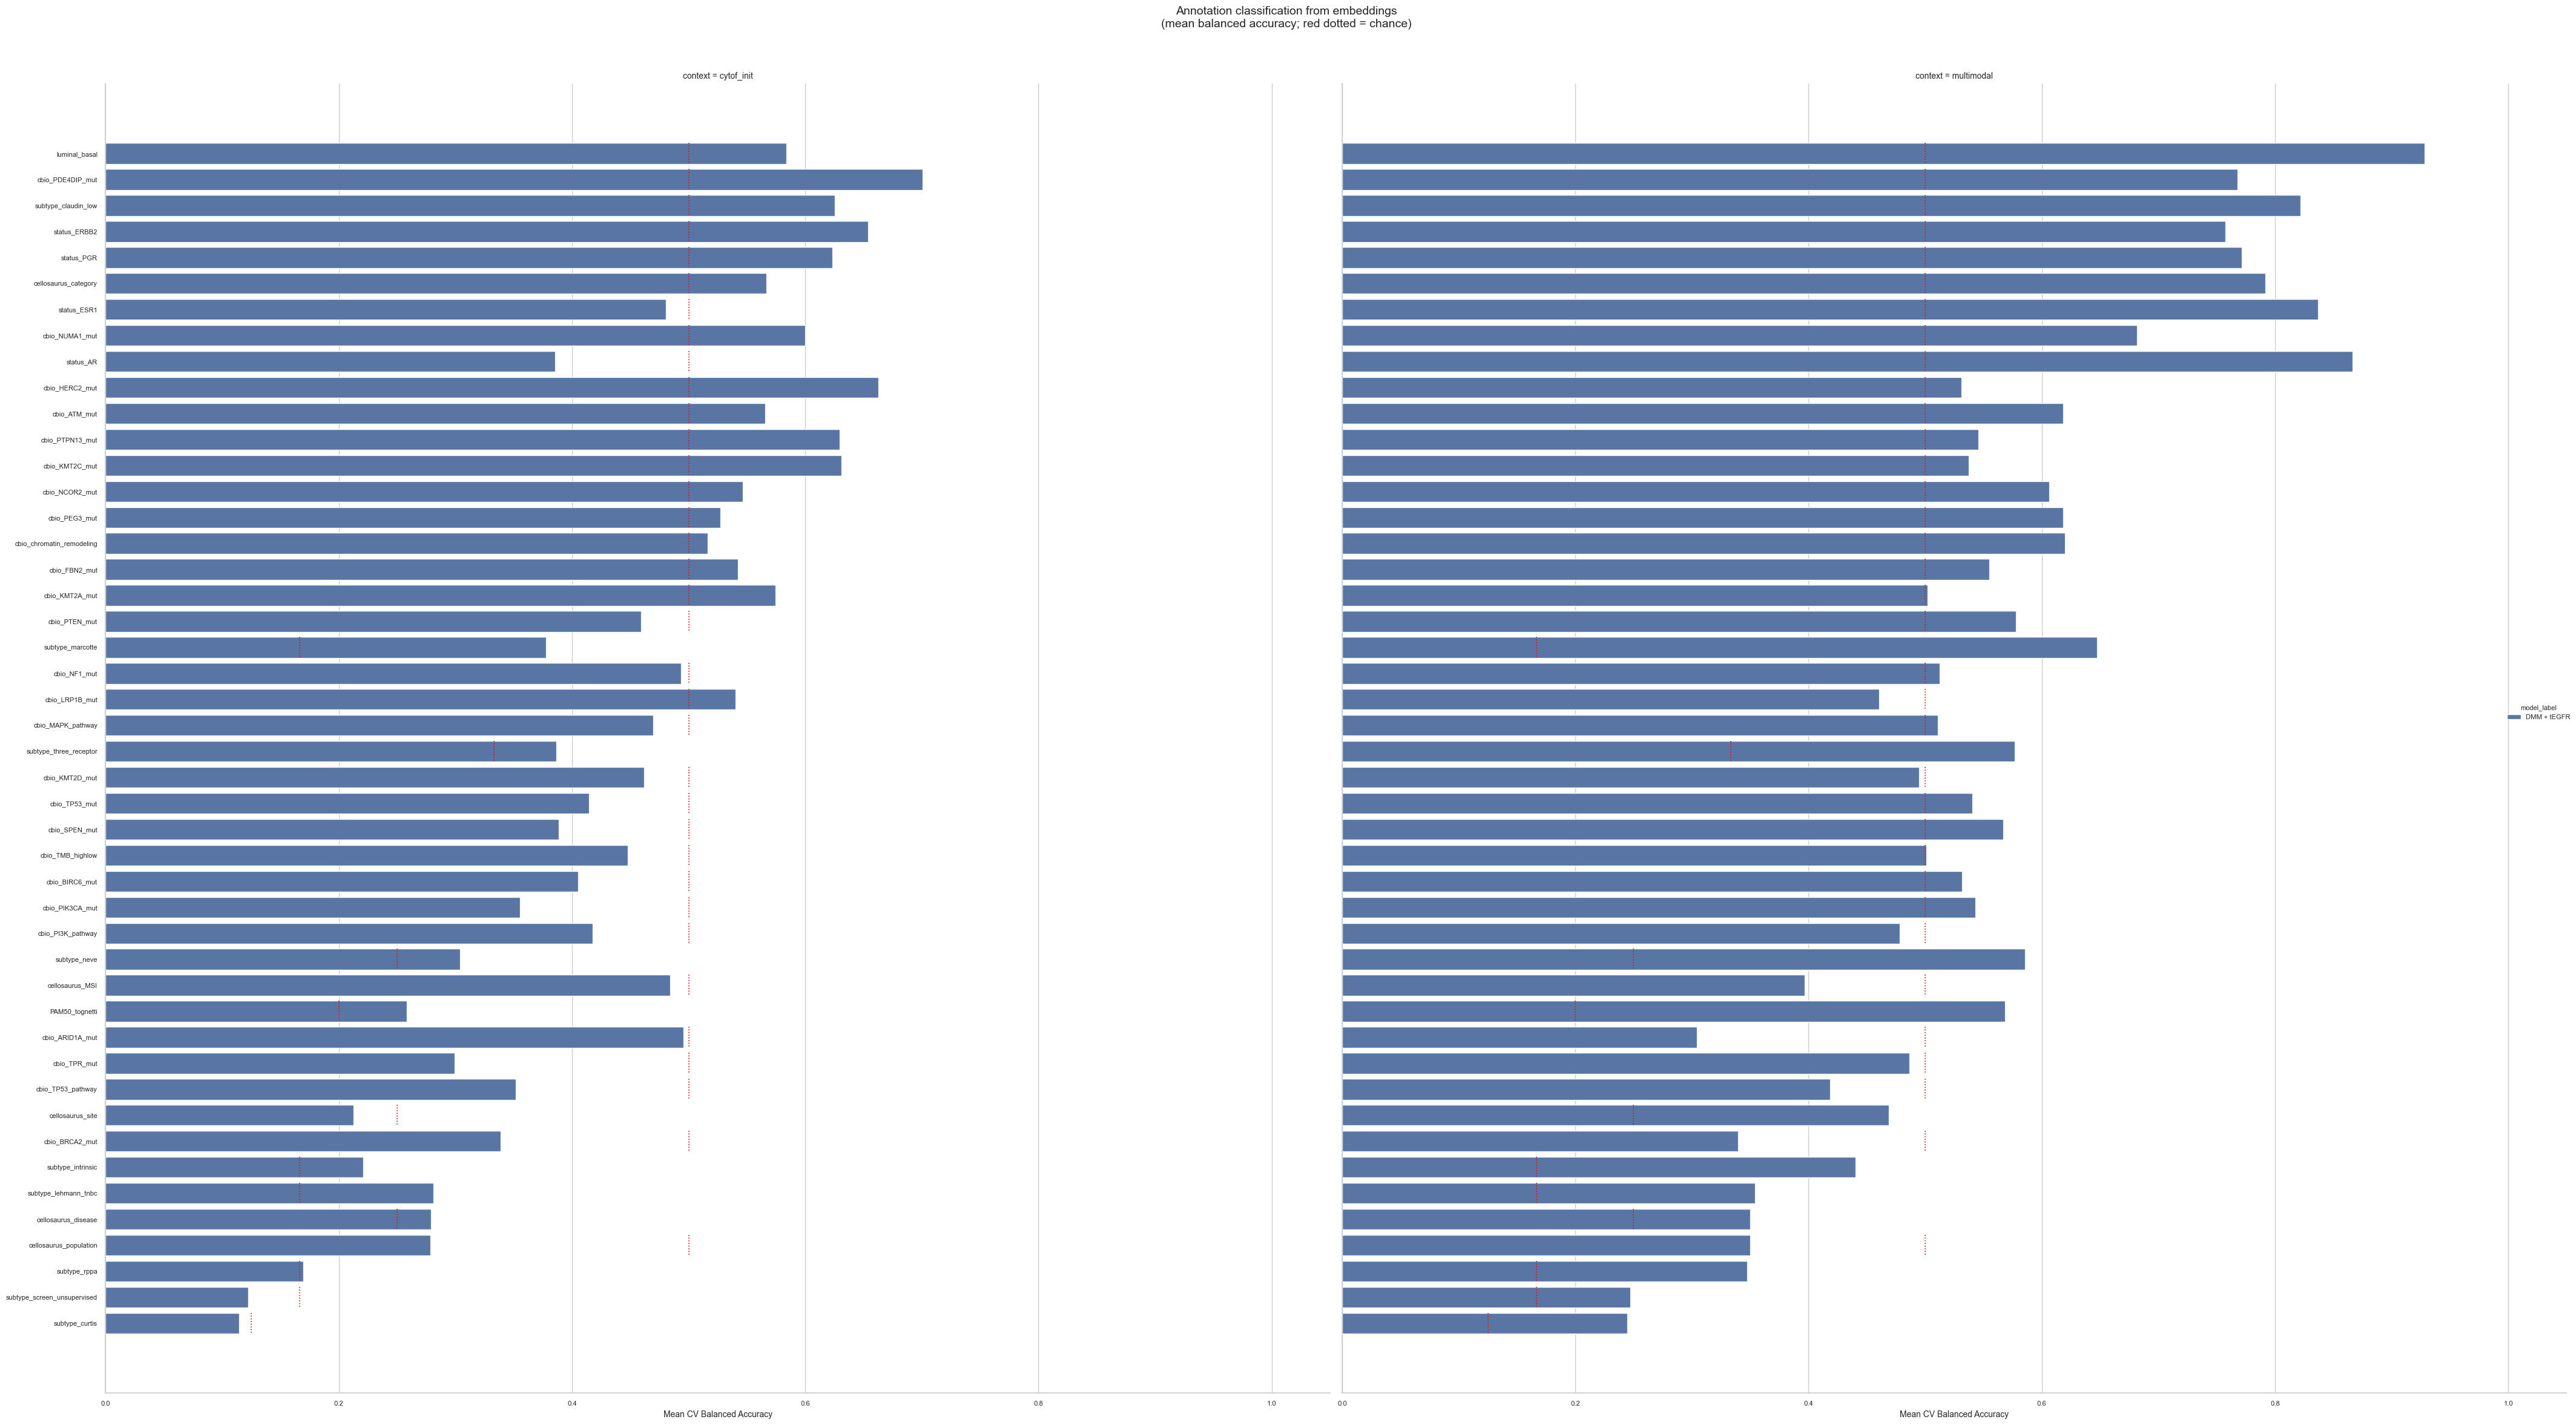

In [46]:
# ── Grouped bar chart: balanced accuracy per annotation, grouped by model, faceted by context ──
plot_df = annot_results_df.copy()
plot_df["model_label"] = plot_df["model"].map({
    "EGFR_MAPK__logobs": "DMM",
    "EGFR_MAPK__logobs_tegfr_aggavg": "DMM + tEGFR",
})

# Average across classifiers for a cleaner view
agg = plot_df.groupby(["annotation", "model_label", "context"]).agg(
    balanced_accuracy=("balanced_accuracy", "mean"),
    balanced_accuracy_std=("balanced_accuracy", "std"),
    n_classes=("n_classes", "first"),
    chance_balanced=("chance_balanced", "first"),
).reset_index()

# Sort annotations by overall balanced accuracy
annot_order = agg.groupby("annotation")["balanced_accuracy"].mean().sort_values(ascending=False).index.tolist()

g = sns.catplot(
    data=agg, x="balanced_accuracy", y="annotation", hue="model_label",
    col="context", kind="bar", orient="h",
    order=annot_order, height=max(4, 0.5 * len(annot_order)), aspect=0.9,
    palette=["#4C72B0", "#DD8452"],
)
g.set_xlabels("Mean CV Balanced Accuracy")
g.set_ylabels("")
for ax in g.axes.flat:
    for i, annot_name in enumerate(annot_order):
        chance_val = agg[agg["annotation"] == annot_name]["chance_balanced"].iloc[0]
        ax.plot([chance_val, chance_val], [i - 0.4, i + 0.4], color="red", ls=":", lw=1.2, zorder=5)
    ax.set_xlim(0, 1.05)
g.fig.suptitle("Annotation classification from embeddings\n(mean balanced accuracy; red dotted = chance)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [47]:
# ── Summary table: best classifier per annotation, balanced accuracy, and above-chance ──
summary_rows = []
for annot in annot_results_df["annotation"].unique():
    sub = annot_results_df[annot_results_df["annotation"] == annot]
    n_cls = sub["n_classes"].iloc[0]
    chance = sub["chance_balanced"].iloc[0]

    for ctx in sub["context"].unique():
        ctx_sub = sub[sub["context"] == ctx]
        base_bacc = ctx_sub[ctx_sub["model"] == "EGFR_MAPK__logobs"]["balanced_accuracy"]
        tegfr_bacc = ctx_sub[ctx_sub["model"] == "EGFR_MAPK__logobs_tegfr_aggavg"]["balanced_accuracy"]

        best_base = base_bacc.max() if len(base_bacc) else np.nan
        best_tegfr = tegfr_bacc.max() if len(tegfr_bacc) else np.nan
        best_clf_base = ctx_sub.loc[
            (ctx_sub["model"] == "EGFR_MAPK__logobs") & (ctx_sub["balanced_accuracy"] == best_base), "classifier"
        ]
        best_clf_base = best_clf_base.iloc[0] if len(best_clf_base) else "—"

        summary_rows.append({
            "annotation": annot,
            "n_classes": n_cls,
            "context": ctx,
            "chance": chance,
            "best_base_bacc": best_base,
            "above_chance_base": best_base - chance,
            "best_base_clf": best_clf_base,
            "best_tegfr_bacc": best_tegfr,
            "above_chance_tegfr": best_tegfr - chance,
            "delta": best_tegfr - best_base,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["above_chance_tegfr"], ascending=False)

print("Balanced accuracy summary (best classifier per config):")
display(summary_df.style.format({
    "chance": "{:.3f}",
    "best_base_bacc": "{:.3f}", "best_tegfr_bacc": "{:.3f}",
    "above_chance_base": "{:+.3f}", "above_chance_tegfr": "{:+.3f}",
    "delta": "{:+.3f}",
}).background_gradient(subset=["above_chance_tegfr"], cmap="RdYlGn", vmin=-0.1, vmax=0.4))

Balanced accuracy summary (best classifier per config):


,annotation,n_classes,context,chance,best_base_bacc,above_chance_base,best_base_clf,best_tegfr_bacc,above_chance_tegfr,delta
13,subtype_marcotte,6,multimodal,0.167,nan,+nan,—,0.656,+0.489,+nan
27,luminal_basal,2,multimodal,0.500,nan,+nan,—,0.932,+0.432,+nan
39,PAM50_tognetti,5,multimodal,0.200,nan,+nan,—,0.593,+0.393,+nan
19,status_AR,2,multimodal,0.500,nan,+nan,—,0.883,+0.383,+nan
3,subtype_neve,4,multimodal,0.250,nan,+nan,—,0.600,+0.350,+nan
21,status_ESR1,2,multimodal,0.500,nan,+nan,—,0.837,+0.337,+nan
5,subtype_claudin_low,2,multimodal,0.500,nan,+nan,—,0.835,+0.335,+nan
37,cellosaurus_category,2,multimodal,0.500,nan,+nan,—,0.796,+0.296,+nan
1,subtype_intrinsic,6,multimodal,0.167,nan,+nan,—,0.456,+0.289,+nan
67,cbio_PDE4DIP_mut,2,multimodal,0.500,nan,+nan,—,0.782,+0.282,+nan


## Feature (latent dimension) importance

Which latent dimensions matter most for each annotation? Heatmap shows mean importance (averaged across classifiers, models, and contexts). The scatter plots below use the **top-2 most important** latent dimensions per annotation instead of a fixed L1/L2.

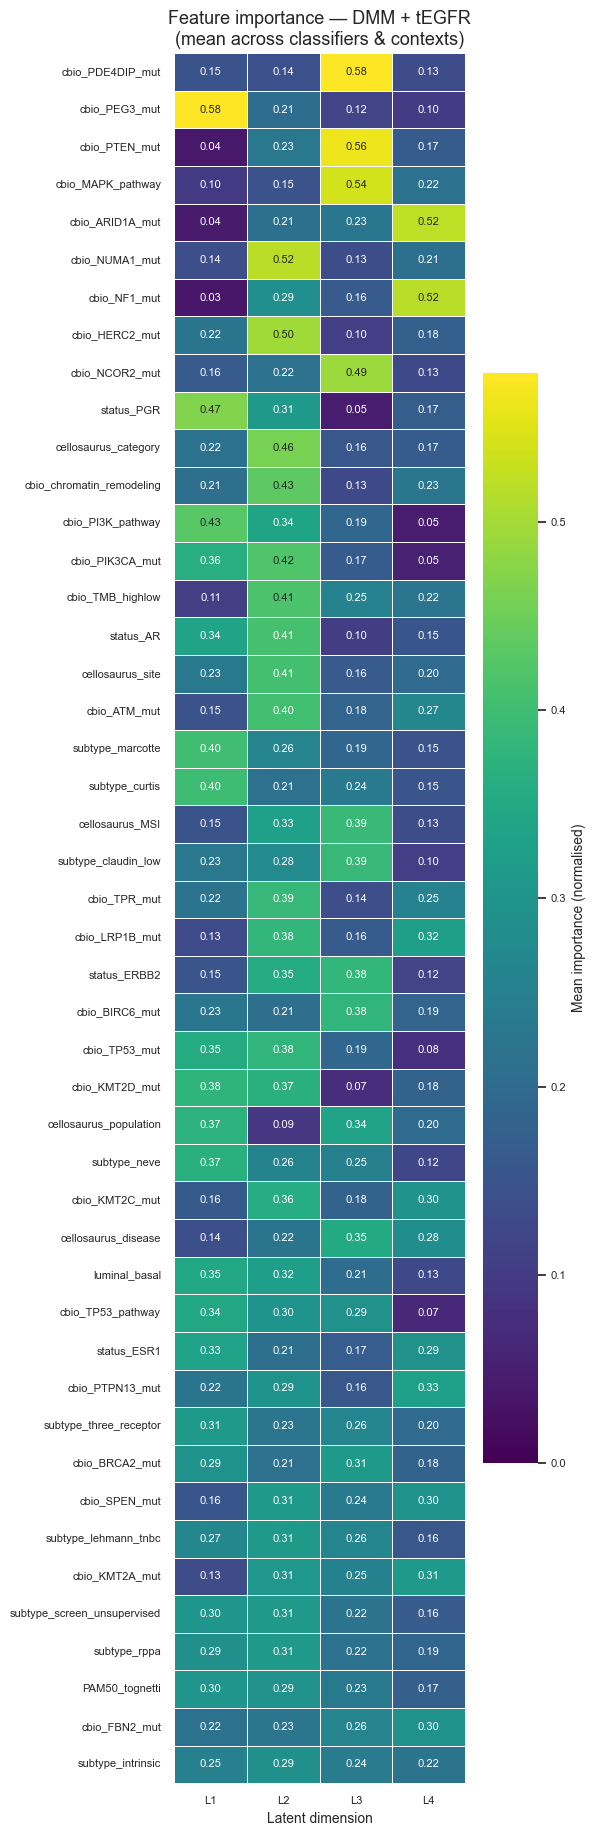


Top-2 latent dims per annotation — DMM + tEGFR:
  cbio_PDE4DIP_mut                     L3, L1
  cbio_PEG3_mut                        L1, L2
  cbio_PTEN_mut                        L3, L2
  cbio_MAPK_pathway                    L3, L4
  cbio_ARID1A_mut                      L4, L3
  cbio_NUMA1_mut                       L2, L4
  cbio_NF1_mut                         L4, L2
  cbio_HERC2_mut                       L2, L1
  cbio_NCOR2_mut                       L3, L2
  status_PGR                           L1, L2
  cellosaurus_category                 L2, L1
  cbio_chromatin_remodeling            L2, L4
  cbio_PI3K_pathway                    L1, L2
  cbio_PIK3CA_mut                      L2, L1
  cbio_TMB_highlow                     L2, L3
  status_AR                            L2, L1
  cellosaurus_site                     L2, L1
  cbio_ATM_mut                         L2, L4
  subtype_marcotte                     L1, L2
  subtype_curtis                       L1, L3
  cellosaurus_MSI              

In [51]:
from embedding_utils import get_top_features_for_annotation

model_labels_imp = {
    "EGFR_MAPK__logobs": "DMM (base)",
    "EGFR_MAPK__logobs_tegfr_aggavg": "DMM + tEGFR",
}

# ── Heatmap: mean feature importance per annotation × latent dimension, one per model ──
if not importance_df.empty:
    for model_name in importance_df["model"].unique():
        model_imp = importance_df[importance_df["model"] == model_name]
        imp_pivot = (
            model_imp
            .groupby(["annotation", "feature"])["importance"]
            .mean()
            .reset_index()
            .pivot(index="annotation", columns="feature", values="importance")
        )
        # Sort columns naturally (L1, L2, ..., L10, ...)
        feat_order = sorted(imp_pivot.columns, key=lambda x: int(x[1:]))
        imp_pivot = imp_pivot[feat_order]

        # Sort rows by max importance (most separable annotation at top)
        imp_pivot = imp_pivot.loc[imp_pivot.max(axis=1).sort_values(ascending=False).index]

        ml = model_labels_imp.get(model_name, model_name)
        fig, ax = plt.subplots(figsize=(max(6, 0.8 * len(feat_order)), max(5, 0.4 * len(imp_pivot))))
        sns.heatmap(
            imp_pivot, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=imp_pivot.values.max(),
            linewidths=0.5, ax=ax, cbar_kws={"label": "Mean importance (normalised)"},
        )
        ax.set_title(f"Feature importance — {ml}\n(mean across classifiers & contexts)", fontsize=13)
        ax.set_ylabel("")
        ax.set_xlabel("Latent dimension")
        plt.tight_layout()
        plt.show()

        # Print top-2 features per annotation for this model
        print(f"\nTop-2 latent dims per annotation — {ml}:")
        for annot in imp_pivot.index:
            top2 = get_top_features_for_annotation(importance_df, annot, model=model_name, top_n=2)
            print(f"  {annot:35s}  {', '.join(top2)}")
        print()
else:
    print("No feature importance data available.")

## Embedding scatter plots for high balanced-accuracy annotations

For annotations with mean **balanced accuracy** ≥ 0.7 (across all classifiers), show embedding scatter plots colored by the annotation label. Each row = one annotation, columns = model × context.

Axes are the two most important latent dimensions for each annotation (from feature importance analysis), rather than always using L1/L2.

Annotations with mean balanced accuracy ≥ 0.7: 4
  luminal_basal                        mean bacc = 0.756
  cbio_PDE4DIP_mut                     mean bacc = 0.734
  subtype_claudin_low                  mean bacc = 0.724
  status_ERBB2                         mean bacc = 0.706


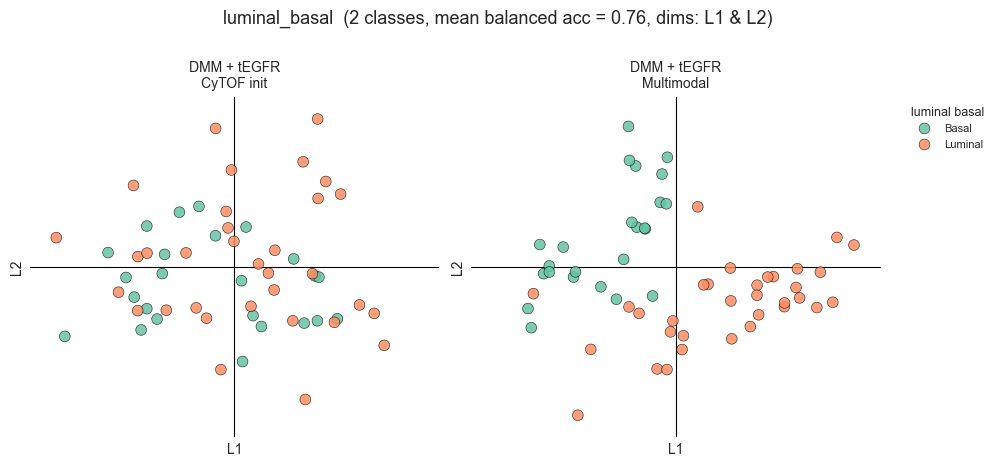

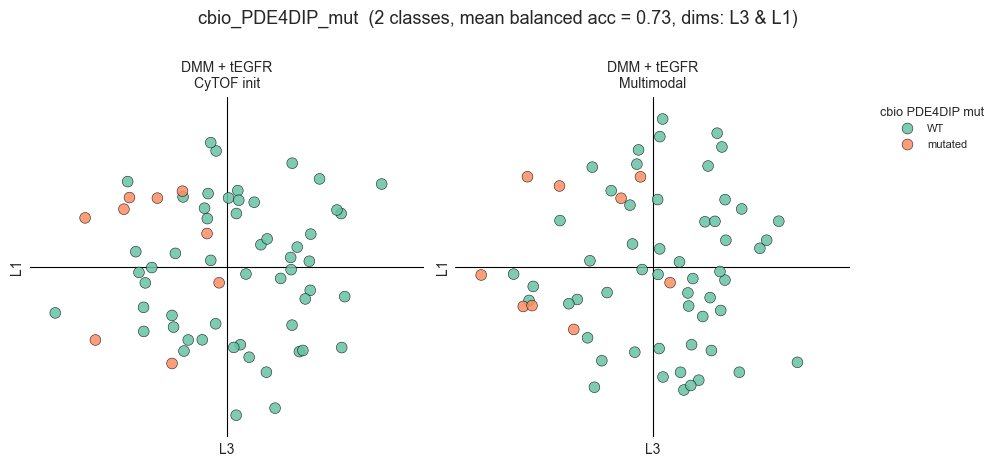

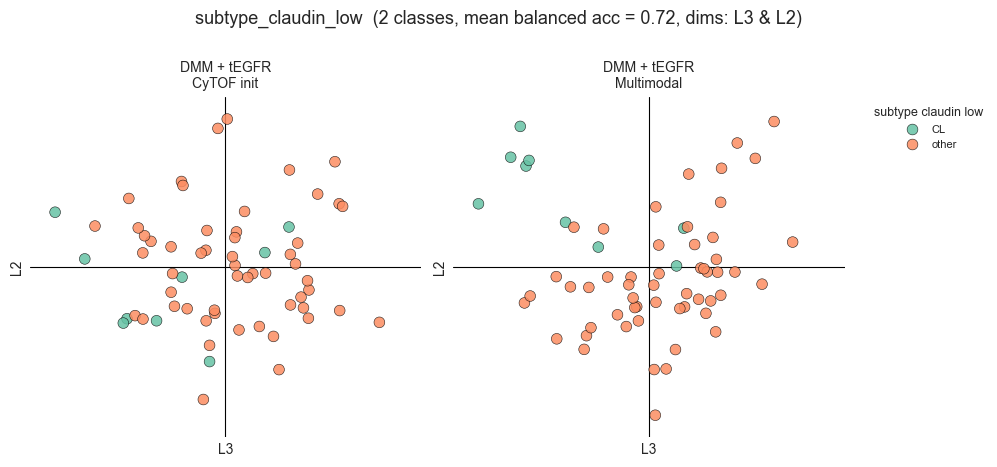

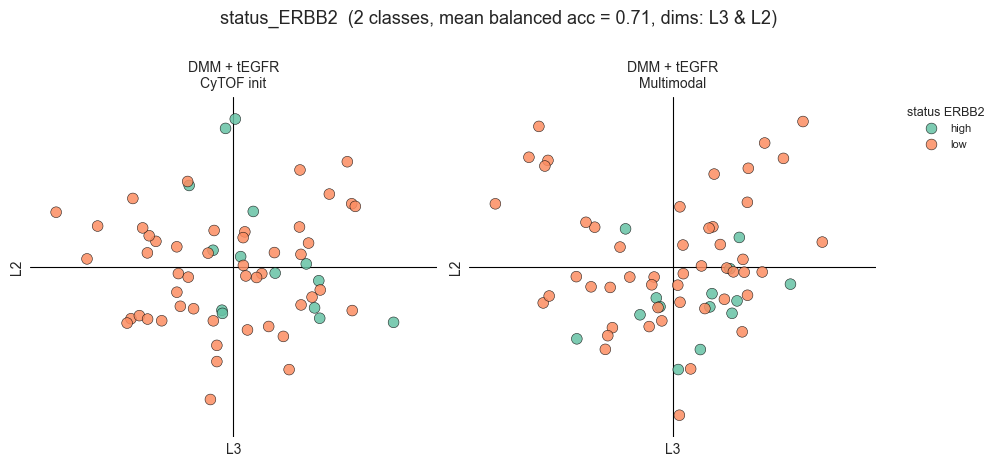

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Identify high balanced-accuracy annotations ──
ACC_THRESHOLD = 0.70
mean_bacc = annot_results_df.groupby("annotation")["balanced_accuracy"].mean()
high_acc_annots = mean_bacc[mean_bacc >= ACC_THRESHOLD].sort_values(ascending=False).index.tolist()
print(f"Annotations with mean balanced accuracy ≥ {ACC_THRESHOLD}: {len(high_acc_annots)}")
for a in high_acc_annots:
    print(f"  {a:35s}  mean bacc = {mean_bacc[a]:.3f}")

# ── Plot embedding scatter for each high-accuracy annotation ──
models_plot = ["EGFR_MAPK__logobs_tegfr_aggavg"]
contexts_plot = ["cytof_init", "multimodal"]
model_labels = {"EGFR_MAPK__logobs": "DMM", "EGFR_MAPK__logobs_tegfr_aggavg": "DMM + tEGFR"}
context_labels = {"cytof_init": "CyTOF init", "multimodal": "Multimodal"}

for annot_name in high_acc_annots:
    annot_ser = annotation_sources[annot_name]
    n_classes = annot_ser.nunique()

    # Choose palette based on number of classes
    if n_classes <= 6:
        palette = "Set2"
    elif n_classes <= 10:
        palette = "tab10"
    else:
        palette = "tab20"

    fig, axes = plt.subplots(
        1,
        len(models_plot) * len(contexts_plot),
        figsize=(5 * len(models_plot) * len(contexts_plot), 4.5),
        squeeze=False,
    )
    axes = axes.flatten()

    idx = 0
    for model in models_plot:
        # Get top-2 features for this specific model
        top_feats = get_top_features_for_annotation(importance_df, annot_name, model=model, top_n=2)
        if len(top_feats) < 2:
            top_feats = ["L1", "L2"]
        x_dim, y_dim = top_feats

        for context in contexts_plot:
            ax = axes[idx]
            emb = pca_clf_df[
                (pca_clf_df["model"] == model) & (pca_clf_df["context"] == context)
            ].copy()
            if emb.empty:
                ax.set_visible(False)
                idx += 1
                continue

            if "cell_line" in emb.columns:
                emb["_annot"] = emb["cell_line"].map(annot_ser)
            else:
                emb["_annot"] = emb.index.map(annot_ser)
            emb = emb.dropna(subset=["_annot"])
            emb = emb.sort_values("_annot")

            sns.scatterplot(
                data=emb,
                x=x_dim,
                y=y_dim,
                hue="_annot",
                palette=palette,
                edgecolor="black",
                linewidth=0.4,
                s=60,
                alpha=0.85,
                ax=ax,
            )

            x_max = max(abs(emb[x_dim].min()), abs(emb[x_dim].max())) * 1.15
            y_max = max(abs(emb[y_dim].min()), abs(emb[y_dim].max())) * 1.15
            ax.set_xlim(-x_max, x_max)
            ax.set_ylim(-y_max, y_max)
            ax.axhline(0, color="black", lw=0.8, zorder=0)
            ax.axvline(0, color="black", lw=0.8, zorder=0)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel(x_dim)
            ax.set_ylabel(y_dim)
            ax.set_title(f"{model_labels[model]}\n{context_labels[context]}", fontsize=10)
            ax.grid(False)
            sns.despine(ax=ax, left=True, bottom=True)

            if idx < len(axes) - 1:
                ax.legend().remove()
            else:
                ax.legend(
                    title=annot_name.replace("_", " "),
                    bbox_to_anchor=(1.05, 1),
                    loc="upper left",
                    frameon=False,
                    fontsize=8,
                    title_fontsize=9,
                )
            idx += 1

    # Use top features from the first model for suptitle (they're shown in per-subplot axes anyway)
    top_feats_title = get_top_features_for_annotation(importance_df, annot_name, model=models_plot[0], top_n=2)
    if len(top_feats_title) < 2:
        top_feats_title = ["L1", "L2"]
    bacc_str = f"mean balanced acc = {mean_bacc[annot_name]:.2f}"
    fig.suptitle(
        f"{annot_name}  ({n_classes} classes, {bacc_str}, dims: {top_feats_title[0]} & {top_feats_title[1]})",
        fontsize=13,
        y=1.02,
    )
    fig.tight_layout()
    plt.show()